#### Phase A: King of Suzuka S-Curves(Performance Baseline Analysis)
#### 🎯 Analysis Overview 
In this phase, we transition from raw data to actionable insights by establishing a **Performance Baseline** for the 2024 Japanese Grand Prix. Apodted a **Holistic View** to categorize the entire grid's technical proficiency in the iconic "S-Curves" (Sector 1).
#### 🔍 Professional Perspectives
* **Performance Tiering**:
    Categorizing all 20 drivers into **A-Tier (Elite)** and **B-Tier (Mid-field)** based on their mean Sector 1 durations. This identifies which car-driver packages mastered the most technical part of the track.

* **Data Integrity & Noise Reduction**:
    Implementing strict filtering to remove **Pit Laps** and **In-laps** (outliers > 35s), ensuring the baseline represents true competitive race pace.

#### ✨ Highlights
* **Big Data Governance**: Process and clean a massive F1 dataset (200k+ rows) to find a "Single Source of Truth."

In [1]:
# STEP 1: Data ingestion & Cleaning

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# load data 
df = pd.read_csv('data/japan_2024_laps.csv')

# drop null
df = df .dropna(subset=['duration_sector_1'])

# remove outliers (pit-stop >35 sec)
df_clean = df[df['duration_sector_1'] < 35]
print(f'Totla clean laps:{len(df_clean)}')

Totla clean laps:296


In [2]:
# STEP 2: Baseline Calculation & Tiering

#Calculate the mean S1 time for all drivers to estabilsh the overall baseline
baseline = df_clean['duration_sector_1'].mean()
print(f'Overall Sector 1 Baseline:{baseline:.3f}s\n')

#group by driver, calculate mean, and sort to identify top and bottom performers.
driver_performance = df_clean.groupby('driver_number')['duration_sector_1'].mean().sort_values()
print('Driver Rankings (Lower is Faster):\n', driver_performance)


Overall Sector 1 Baseline:34.497s

Driver Rankings (Lower is Faster):
 driver_number
55    34.094889
11    34.310933
44    34.393192
63    34.396625
1     34.427706
81    34.433381
14    34.511842
2     34.526588
16    34.588583
4     34.615226
18    34.708438
27    34.757800
31    34.785222
77    34.798714
22    34.887750
10    34.931167
Name: duration_sector_1, dtype: float64


count    296.000000
mean      34.496639
std        0.365491
min       33.310000
25%       34.223000
50%       34.531000
75%       34.826750
max       34.998000
Name: duration_sector_1, dtype: float64


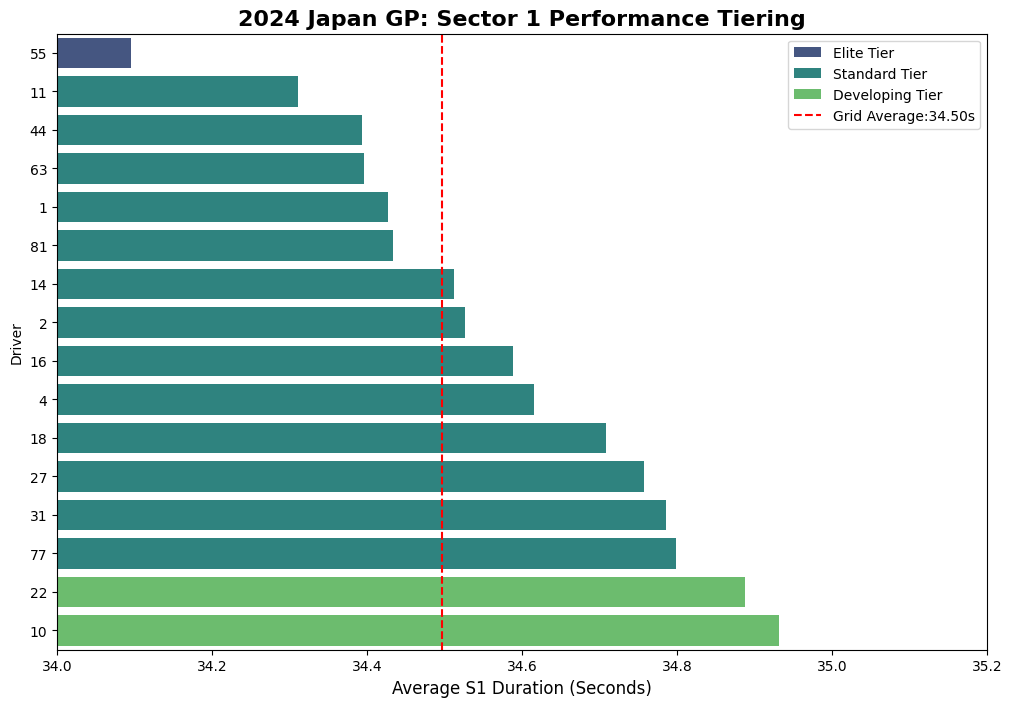

In [3]:
# FINAL STEP: Automated performance Tiering Plot

#Find Tiering sector
print(df_clean['duration_sector_1'].describe())

#Convert series to DataFrame
rank_df = driver_performance.reset_index()
rank_df.columns = ['Driver','Avg_S1']

#Define Tiers baesd on speed
def assign_tier(time):
    if time < 34.223: #top 25% from describe
        return 'Elite Tier'
    elif time < 34.826: #25%-75% 
        return 'Standard Tier'
    else:
        return 'Developing Tier'

rank_df['Tier'] = rank_df['Avg_S1'].apply(assign_tier)

#Sort by Tier then Speed
tier_order = ['Elite Tier', 'Standard Tier', 'Developing Tier']
rank_df['Tier'] = pd.Categorical(rank_df['Tier'], categories=tier_order, ordered=True)
rank_df_sorted = rank_df.sort_values(by=['Tier','Avg_S1'])

#force to reset the index
rank_df_sorted = rank_df_sorted.reset_index(drop=True)

#Plotting the tiered bar chart
plt.figure(figsize=(12,8))
sns.barplot(data=rank_df_sorted,
            x='Avg_S1',
            y=rank_df_sorted['Driver'].astype(str), #Force cast Driver to string to break Seaborn's categorical memory and ensure the plot follows the DataFrame's sorted order.
            hue='Tier',
            orient='h',
            palette='viridis',
            dodge=False)
#add baseline reference
grid_avg = df_clean['duration_sector_1'].mean()
plt.axvline(grid_avg,
            color='red',
            linestyle='--',
            label=f'Grid Average:{grid_avg:.2f}s')

plt.title('2024 Japan GP: Sector 1 Performance Tiering', fontsize=16, fontweight='bold')
plt.xlabel('Average S1 Duration (Seconds)', fontsize=12)
plt.xlim(34, 35.2)  # Narrow down the scope to highlight the differences
plt.legend()

#Save and Show
plt.savefig('visualizations/sector1_tiering.png')
plt.show()

**Phase A Analysis: The Technical Mastery of Sector 1 (Suzuka)**

In this Phase A analysis of the 2024 Japanese GP, we focused exclusively on Sector 1 (The S-Curves) to evaluate high-speed technical proficiency.

The results yield a surprising insight: while Max Verstappen dominated the overall race, Carlos Sainz (#55) recorded the fastest average time in Sector 1, effectively outperforming Sergio Pérez by nearly 0.2 seconds in this specific segment.

Our visualization reveals a high-density performance distribution, where a significant majority of the grid performed faster than the global mean. This suggests that in professional F1 standards, the margin for error in technical sectors is extreme, with elite drivers like Sainz extracting marginal gains that could be pivotal for qualifying and tire management strategies.